<a href="https://colab.research.google.com/github/luvuvamocaixa-ai/luvuvamo_projetos-/blob/main/Desafio_Fifa_World_Cup_Gold_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

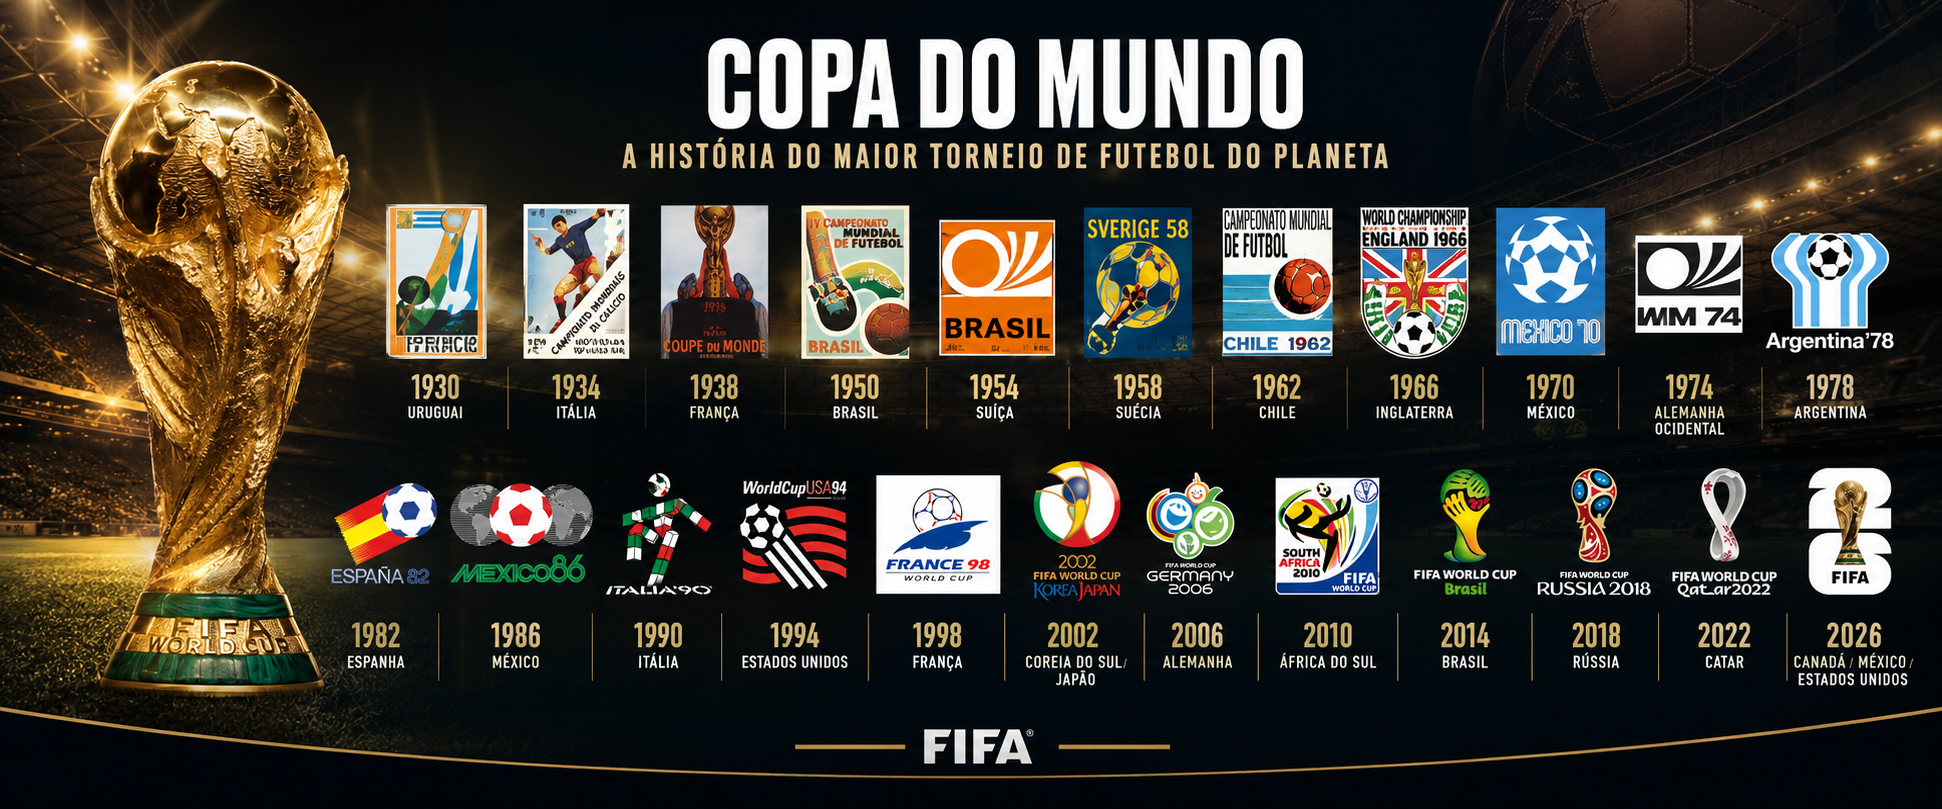


# **MOUNT DRIVE**
### 🥇 Desafio FIFA World Cup — Gold 4/4

Quarta e última etapa do projeto e **quarto notebook do pipeline**, responsável pela construção da **Camada Gold** da Arquitetura Medalhão.

Nesta etapa, os dados da Camada Silver são organizados em um **modelo dimensional**, separando **tabelas de dimensões e fatos**. O objetivo é disponibilizar dados estruturados, consistentes e preparados para análises e criação de dashboards no **Power BI**.

### 🔄 Fluxo completo

**Kaggle → Google Drive → Bronze → Silver → Gold → Power BI**

A Camada Gold representa a etapa final de transformação do pipeline, disponibilizando um **modelo analítico estruturado** para exploração dos dados da FIFA World Cup e construção de indicadores e dashboards no **Power BI**.

**Tecnologias:** Google Colab • Python • PySpark • SQL • Google Drive • Power BI


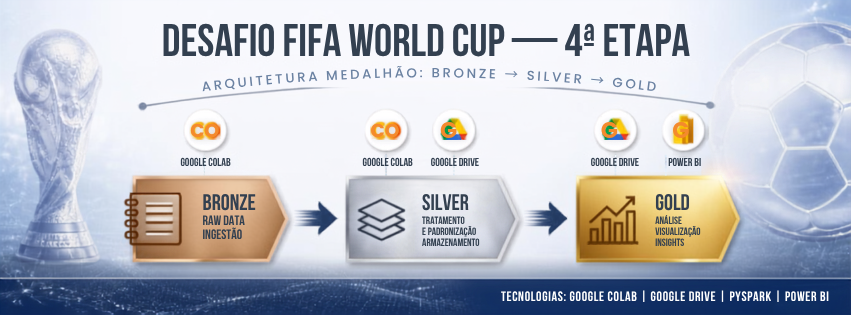

In [ ]:
!pip install -q kagglehub pyspark

In [ ]:
import os
import glob
import shutil
import kagglehub
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.window import Window
from pyspark.sql import functions as F
from pyspark.sql.functions import datediff
from pyspark.sql.functions import when, col, trim, to_date, concat_ws, lit, round

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Builder Spark Session**

In [ ]:
spark = SparkSession.builder \
    .appName("FIFA World Cup") \
    .getOrCreate()

# **# CAMADA GOLD**

##🥉 Tabelas GOLD


### 📊 Estrutura da Camada Gold

**GOLD**

├── **DIMENSIONS**

│   ├── **dim_tempo** — informações relacionadas a datas, anos e períodos.

│   ├── **dim_edicao** — informações sobre cada edição da Copa do Mundo.

│   ├── **dim_time** — cadastro e características das seleções participantes.

│   ├── **dim_local** — informações sobre países, cidades e locais relacionados às partidas.

│   ├── **dim_estagio** — fases e estágios da competição, como grupos, oitavas, quartas, semifinal e final.

│   └── **dim_jogador** — informações dos jogadores e suas respectivas seleções.


└── **FACTS**

├── **fato_partida** — registros e métricas das partidas realizadas, incluindo equipes e resultados.

├── **fato_artilharia** — dados de gols e desempenho dos jogadores na artilharia.

└── **fato_fixtures_2026** — dados das partidas programadas para a FIFA World Cup 2026.



In [ ]:
SILVER_PATH = "/content/drive/MyDrive/Desafio_FIFA_World_Cup/silver"
GOLD_PATH = "/content/drive/MyDrive/Desafio_FIFA_World_Cup/gold"

In [ ]:

silver_matches = spark.read.parquet(
    f"{SILVER_PATH}/matches"
)

silver_editions = spark.read.parquet(
    f"{SILVER_PATH}/editions"
)

silver_teams_2026 = spark.read.parquet(
    f"{SILVER_PATH}/teams_2026"
)

silver_top_scorers = spark.read.parquet(
    f"{SILVER_PATH}/top_scorers"
)

silver_fixtures_2026 = spark.read.parquet(
    f"{SILVER_PATH}/fixtures_2026"
)

## **Tabela Dim_time**

In [ ]:
# ============================================================
# GOLD - DIM_TIME
# ============================================================

times_matches = (
    silver_matches
        .select(
            F.col("team1").alias("team")
        )
        .union(
            silver_matches
                .select(
                    F.col("team2").alias("team")
                )
        )
)


times_fixtures = (
    silver_fixtures_2026
        .select(
            F.col("team1").alias("team")
        )
        .union(
            silver_fixtures_2026
                .select(
                    F.col("team2").alias("team")
                )
        )
)


times_2026 = (
    silver_teams_2026
        .select("team")
)


dim_time_base = (
    times_matches
        .union(times_fixtures)
        .union(times_2026)

        .where(
            F.col("team").isNotNull()
        )

        .where(
            F.trim(F.col("team")) != ""
        )

        .withColumn(
            "team",
            F.trim(F.col("team"))
        )

        .distinct()
)


teams_2026 = (
    silver_teams_2026

        .select(
            "team",
            "group",
            "confederation",
            "fifa_rank",
            "coach",
            "best_wc_result",
            "debut_2026"
        )

        .withColumn(
            "team",
            F.trim(F.col("team"))
        )

        .dropDuplicates(["team"])
)


dim_time = (
    dim_time_base.alias("d")

        .join(
            teams_2026.alias("t"),

            F.col("d.team") ==
            F.col("t.team"),

            "left"
        )

        .select(

            F.col("d.team").alias(
                "team"
            ),

            F.col("t.group").alias(
                "group"
            ),

            F.col("t.confederation").alias(
                "confederation"
            ),

            F.col("t.fifa_rank").alias(
                "fifa_rank"
            ),

            F.col("t.coach").alias(
                "coach"
            ),

            F.col("t.best_wc_result").alias(
                "best_wc_result"
            ),

            F.col("t.debut_2026").alias(
                "debut_2026"
            )
        )
)


window_time = Window.orderBy("team")

dim_time = (
    dim_time

        .withColumn(
            "sk_time",
            F.row_number().over(
                window_time
            )
        )

        .select(
            "sk_time",
            "team",
            "group",
            "confederation",
            "fifa_rank",
            "coach",
            "best_wc_result",
            "debut_2026"
        )
)

dim_time = dim_time.orderBy("sk_time")

dim_time.write \
    .mode("overwrite") \
    .parquet(f"{GOLD_PATH}/dim_time")


## **Tabela Dim_edicao**

In [ ]:
dim_edicao = (
    silver_editions
    .select(
        F.col("edition").cast("int").alias("sk_edicao"),
        F.col("edition").cast("int").alias("edicao"),
        F.col("year").cast("int").alias("ano"),
        "host",
        "champion",
        "runner_up",
        "third_place",
        "fourth_place",
        "teams",
        "matches",
        "goals",
        "goals_per_match",
        "attendance",
        "top_scorer",
        "top_scorer_country",
        "top_scorer_goals",
        "start_date",
        "end_date",
        "final_city",
        "host_won",
        "format",
        "tournament_days"
    )
    .dropDuplicates(["sk_edicao"])
)

dim_edicao.write \
    .mode("overwrite") \
    .parquet(f"{GOLD_PATH}/dim_edicao")

## **Tabela Dim_tempo**

In [ ]:
# ============================================================
# GOLD - DIM_TEMPO
# ============================================================

datas_matches = (
    silver_matches
        .select(
            F.to_date(
                "match_date"
            ).alias("data")
        )
        .where(
            F.col("data").isNotNull()
        )
)


datas_fixtures = (
    silver_fixtures_2026
        .select(
            F.to_date(
                "match_date"
            ).alias("data")
        )
        .where(
            F.col("data").isNotNull()
        )
)


datas = (
    datas_matches
        .union(datas_fixtures)
        .distinct()
)


data_min_max = (
    datas
        .agg(
            F.min("data").alias(
                "data_min"
            ),

            F.max("data").alias(
                "data_max"
            )
        )
        .collect()[0]
)


data_min = data_min_max["data_min"]

data_max = data_min_max["data_max"]


dim_tempo = (
    spark.sql(
        f"""
        SELECT
            explode(
                sequence(
                    to_date('{data_min}'),
                    to_date('{data_max}'),
                    interval 1 day
                )
            ) AS data
        """
    )


    .withColumn(
        "sk_tempo",

        F.date_format(
            "data",
            "yyyyMMdd"
        ).cast("int")
    )

    .withColumn(
        "ano",
        F.year("data")
    )


    .withColumn(
        "mes",
        F.month("data")
    )


    .withColumn(
        "nome_mes",
        F.date_format(
            "data",
            "MMMM"
        )
    )

    .withColumn(
        "trimestre",
        F.quarter("data")
    )

    .withColumn(
        "dia",
        F.dayofmonth("data")
    )

    .withColumn(
        "dia_semana",
        F.dayofweek("data")
    )

    .withColumn(
        "nome_dia_semana",
        F.date_format(
            "data",
            "EEEE"
        )
    )
)

dim_tempo = dim_tempo.select(

    "sk_tempo",

    "data",

    "ano",

    "mes",

    "nome_mes",

    "trimestre",

    "dia",

    "dia_semana",

    "nome_dia_semana"
)


dim_tempo = (
    dim_tempo
        .orderBy("data")
)


dim_tempo.write \
    .mode("overwrite") \
    .parquet(f"{GOLD_PATH}/dim_tempo")

## **Tabela Dim_local**

In [ ]:
dim_local = (
    silver_matches
    .select(
        "venue",
        "city",
        "country"
    )
    .union(
        silver_fixtures_2026.select(
            "venue",
            "city",
            "country"
        )
    )
    .where(F.col("venue").isNotNull())
    .distinct()
    .withColumn(
        "sk_local",
        F.row_number().over(
            Window.orderBy("country", "city", "venue")
        )
    )
)

dim_local.write \
    .mode("overwrite") \
    .parquet(f"{GOLD_PATH}/dim_local")

## **Tabela Dim_estagio**

In [ ]:
dim_estagio = (
    silver_matches
    .select("stage")
    .union(
        silver_fixtures_2026.select("stage")
    )
    .where(F.col("stage").isNotNull())
    .distinct()
    .withColumn(
        "sk_estagio",
        F.row_number().over(
            Window.orderBy("stage")
        )
    )
)

dim_estagio.write \
    .mode("overwrite") \
    .parquet(f"{GOLD_PATH}/dim_estagio")

## **Tabela Dim_jogador**

In [ ]:
dim_jogador = (
    silver_top_scorers
    .select(
        "player",
        "country",
        "position"
    )
    .where(F.col("player").isNotNull())
    .distinct()
    .withColumn(
        "sk_jogador",
        F.row_number().over(
            Window.orderBy("player")
        )
    )
)

dim_jogador.write \
    .mode("overwrite") \
    .parquet(f"{GOLD_PATH}/dim_jogador")

## **Tabela Fato_partida**

In [ ]:

fato_partida = (
    silver_matches.alias("m")

    .join(
        dim_tempo.select(
            "sk_tempo",
            "data"
        ).alias("t"),
        F.to_date(F.col("m.match_date")) == F.col("t.data"),
        "left"
    )

    .join(
        dim_edicao.select(
            "sk_edicao",
            "ano"
        ).alias("e"),
        F.col("m.year") == F.col("e.ano"),
        "left"
    )

    .join(
        dim_time.select(
            F.col("sk_time").alias("sk_time1"),
            F.col("team").alias("team1")
        ).alias("t1"),
        F.col("m.team1") == F.col("t1.team1"),
        "left"
    )

    .join(
        dim_time.select(
            F.col("sk_time").alias("sk_time2"),
            F.col("team").alias("team2")
        ).alias("t2"),
        F.col("m.team2") == F.col("t2.team2"),
        "left"
    )

    .join(
        dim_local.select(
            "sk_local",
            "venue",
            "city",
            "country"
        ).alias("l"),
        (
            (F.col("m.venue") == F.col("l.venue")) &
            (F.col("m.city") == F.col("l.city")) &
            (F.col("m.country") == F.col("l.country"))
        ),
        "left"
    )

    .join(
        dim_estagio.select(
            "sk_estagio",
            "stage"
        ).alias("s"),
        F.col("m.stage") == F.col("s.stage"),
        "left"
    )
)



fato_partida = fato_partida.select(
    F.monotonically_increasing_id().alias("sk_partida"),

    "sk_tempo",
    "sk_edicao",
    F.col("sk_time1"),
    F.col("sk_time2"),
    "sk_local",
    "sk_estagio",

    F.col("m.year").alias("ano"),

    F.col("m.score1").cast("int").alias("gols_time1"),
    F.col("m.score2").cast("int").alias("gols_time2"),

    F.col("m.total_goals").cast("int").alias("total_gols"),

    F.col("m.goal_difference").cast("int").alias(
        "diferenca_gols"
    ),

    F.col("m.match_result").alias("resultado"),

    F.col("m.is_draw").alias("empate"),

    F.col("m.notes").alias("observacoes")
)

fato_partida.write \
    .mode("overwrite") \
    .parquet(f"{GOLD_PATH}/fato_partida")

## **Tabela Fato_artilharia**

In [ ]:
fato_artilharia = (
    silver_top_scorers.alias("s")

    .join(
        dim_jogador.select(
            "sk_jogador",
            "player"
        ).alias("j"),
        F.col("s.player") == F.col("j.player"),
        "left"
    )

    .join(
        dim_edicao.select(
            "sk_edicao",
            "ano"
        ).alias("e"),
        F.col("s.year") == F.col("e.ano"),
        "left"
    )
)


fato_artilharia = fato_artilharia.select(
    F.monotonically_increasing_id().alias("sk_artilharia"),

    "sk_jogador",
    "sk_edicao",

    F.col("s.goals").cast("int").alias("gols"),
    F.col("s.assists").cast("int").alias("assistencias"),
    F.col("s.penalties").cast("int").alias("penaltis"),
    F.col("s.matches_played").cast("int").alias(
        "partidas_jogadas"
    ),

    F.col("s.goals_per_match").cast("double").alias(
        "gols_por_partida"
    ),

    F.col("s.assists_per_match").cast("double").alias(
        "assistencias_por_partida"
    ),

    F.col("s.team_result").alias("resultado_time"),
    F.col("s.host").alias("pais_sede")
)


fato_artilharia.write \
    .mode("overwrite") \
    .parquet(f"{GOLD_PATH}/fato_artilharia")

## **Tabela Fato_fixtures_2026**

In [ ]:
fato_fixtures_2026 = (
    silver_fixtures_2026.alias("f")

    .join(
        dim_tempo.select(
            "sk_tempo",
            "data"
        ).alias("t"),
        F.to_date(F.col("f.match_date")) == F.col("t.data"),
        "left"
    )

    .join(
        dim_time.select(
            F.col("sk_time").alias("sk_time1"),
            F.col("team").alias("team1")
        ).alias("t1"),
        F.col("f.team1") == F.col("t1.team1"),
        "left"
    )

    .join(
        dim_time.select(
            F.col("sk_time").alias("sk_time2"),
            F.col("team").alias("team2")
        ).alias("t2"),
        F.col("f.team2") == F.col("t2.team2"),
        "left"
    )

    .join(
        dim_local.select(
            "sk_local",
            "venue",
            "city",
            "country"
        ).alias("l"),
        (
            (F.col("f.venue") == F.col("l.venue")) &
            (F.col("f.city") == F.col("l.city")) &
            (F.col("f.country") == F.col("l.country"))
        ),
        "left"
    )

    .join(
        dim_estagio.select(
            "sk_estagio",
            "stage"
        ).alias("s"),
        F.col("f.stage") == F.col("s.stage"),
        "left"
    )
)


fato_fixtures_2026 = fato_fixtures_2026.select(
    F.monotonically_increasing_id().alias("sk_fixture"),

    "sk_tempo",
    "sk_time1",
    "sk_time2",
    "sk_local",
    "sk_estagio",

    F.col("f.year").alias("ano"),

    F.col("f.score1").cast("int").alias("gols_time1"),
    F.col("f.score2").cast("int").alias("gols_time2"),

    F.col("f.total_goals").cast("int").alias("total_gols"),

    F.col("f.goal_difference").cast("int").alias(
        "diferenca_gols"
    ),

    F.col("f.match_status").alias("status_partida"),

    F.col("f.match_result").alias("resultado"),

    F.col("f.notes").alias("observacoes")
)


fato_fixtures_2026.write \
    .mode("overwrite") \
    .parquet(f"{GOLD_PATH}/fato_fixtures_2026")

## 🏆 Conclusão — Desafio FIFA World Cup

E assim concluímos o **Desafio FIFA World Cup — Gold 4/4** no notebook `Desafio_Fifa_World_Cup_Gold_4`.

Neste projeto, foi desenvolvido um pipeline completo de **Engenharia de Dados**, desde a extração dos dados no Kaggle até a disponibilização das informações na **Camada Gold**, utilizando a **Arquitetura Medalhão (Bronze → Silver → Gold)**.

O projeto envolveu **ingestão, armazenamento, tratamento, transformação e modelagem dimensional**, resultando em dados estruturados e preparados para análise e visualização no **Power BI**.

**🚀 Projeto concluído: da origem dos dados ao dashboard analítico!**

**Tecnologias:** Python • PySpark • SQL • KaggleHub • Google Colab • Google Drive • Power BI


In [ ]:
print("DIMENSÕES")
print("dim_tempo:", dim_tempo.count())
print("dim_edicao:", dim_edicao.count())
print("dim_time:", dim_time.count())
print("dim_local:", dim_local.count())
print("dim_estagio:", dim_estagio.count())
print("dim_jogador:", dim_jogador.count())

print("\nFATOS")
print("fato_partida:", fato_partida.count())
print("fato_artilharia:", fato_artilharia.count())
print("fato_fixtures_2026:", fato_fixtures_2026.count())

DIMENSÕES
dim_tempo: 160
dim_edicao: 22
dim_time: 71
dim_local: 105
dim_estagio: 8
dim_jogador: 22

FATOS
fato_partida: 184
fato_artilharia: 22
fato_fixtures_2026: 184
